FINDING TOP WINNERS 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_cups = pd.read_csv("../data/processed/cups_clean.csv")
df_matches = pd.read_csv("../data/processed/matches_clean.csv")

In [4]:
# finding the winners
df_cups['Winner'].value_counts()
top_winners = df_cups['Winner'].value_counts().head(10)
print(top_winners)

Winner
Brazil        5
Italy         4
Germany FR    3
Uruguay       2
Argentina     2
England       1
France        1
Spain         1
Germany       1
Name: count, dtype: int64


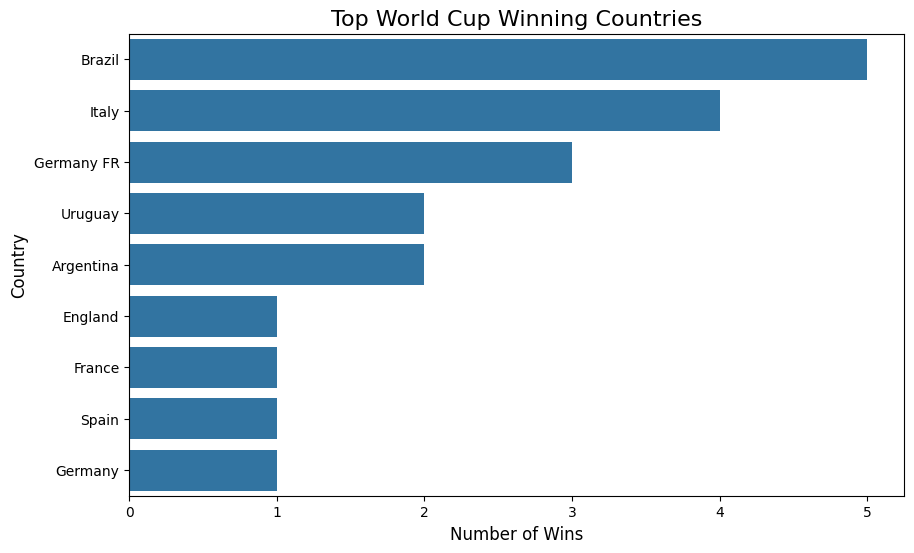

In [5]:
fig, ax = plt.subplots(figsize= (10,6))
sns.barplot(x=top_winners, y=top_winners.index, ax=ax)
ax.set_title('Top World Cup Winning Countries', fontsize= 16)
ax.set_xlabel('Number of Wins',fontsize= 12)
ax.set_ylabel('Country',fontsize= 12)
# save the plot
plt.savefig('../visualizations/top_winners.png',dpi=150,bbox_inches= 'tight')
plt.show()

In [6]:
# in data germany and germany fr are seperate , so combining it
df_cups['Winner'] = df_cups['Winner'].replace('Germany FR', 'Germany')
top_winners = df_cups['Winner'].value_counts().head(10)
print(top_winners)

Winner
Brazil       5
Italy        4
Germany      4
Uruguay      2
Argentina    2
England      1
France       1
Spain        1
Name: count, dtype: int64


## Top 10 highest scoring teams ever

In [7]:
df_matches[['home_team_name','home_team_goals','away_team_name','away_team_goals']].head(10)

,home_team_name,home_team_goals,away_team_name,away_team_goals
0,France,4.0,Mexico,1.0
1,USA,3.0,Belgium,0.0
2,Yugoslavia,2.0,Brazil,1.0
3,Romania,3.0,Peru,1.0
4,Argentina,1.0,France,0.0
5,Chile,3.0,Mexico,0.0
6,Yugoslavia,4.0,Bolivia,0.0
7,USA,3.0,Paraguay,0.0
8,Uruguay,1.0,Peru,0.0
9,Chile,1.0,France,0.0


In [8]:
home_goals = df_matches.groupby('home_team_name')['home_team_goals'].sum()
away_goals = df_matches.groupby('away_team_name')['away_team_goals'].sum()
total_goals = home_goals.add(away_goals, fill_value= 0) #fill_value 0 le chai if euta team home ma matra cha bhane away ma NaN ko satta 0 lekcha
top_scorers = total_goals.sort_values(ascending=False).head(10)
print(top_scorers)


home_team_name
Brazil         225.0
Argentina      133.0
Germany FR     131.0
Italy          128.0
France         108.0
Germany        100.0
Spain           92.0
Netherlands     91.0
Hungary         87.0
Uruguay         80.0
dtype: float64


In [9]:
#germany data are seperate , combining it
df_matches['away_team_name'] = df_matches['away_team_name'].replace('Germany FR', 'Germany')
df_matches['home_team_name'] = df_matches['home_team_name'].replace('Germany FR', 'Germany')

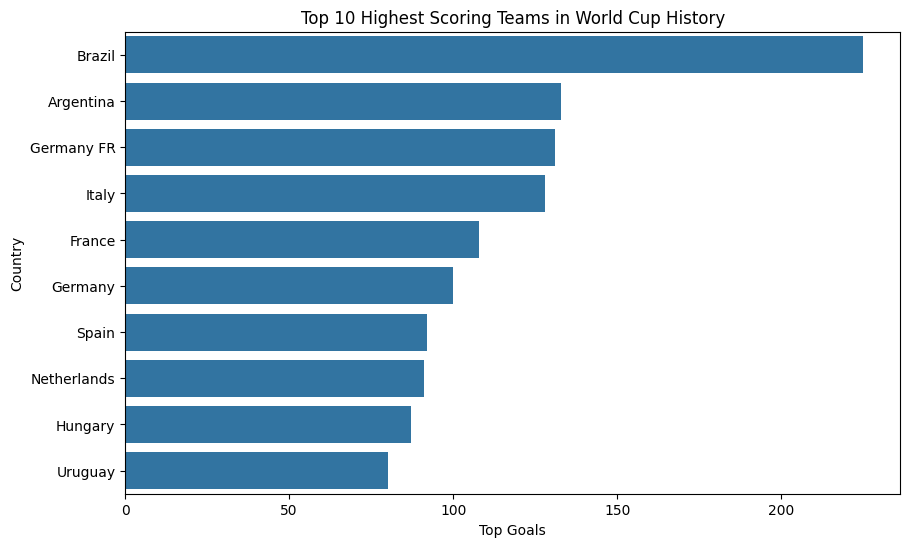

In [10]:
fig, ax = plt.subplots(figsize= (10,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index)
ax.set_title('Top 10 Highest Scoring Teams in World Cup History')
ax.set_xlabel('Top Goals')
ax.set_ylabel('Country')
plt.savefig('../visualizations/top_scorers.png')
plt.show()

## Average goals per match over time


In [11]:
df_matches['total_goals'] = df_matches['home_team_goals'] + df_matches['away_team_goals']
df_matches[['total_goals','home_team_goals', 'away_team_goals']].head()

,total_goals,home_team_goals,away_team_goals
0,5.0,4.0,1.0
1,3.0,3.0,0.0
2,3.0,2.0,1.0
3,4.0,3.0,1.0
4,1.0,1.0,0.0


In [12]:
avg_goals = df_matches.groupby('year')['total_goals'].mean().sort_values(ascending=False)
print(avg_goals)

year
1954    5.384615
1938    4.666667
1934    4.117647
1950    4.000000
1930    3.888889
1958    3.600000
1970    2.968750
1982    2.807692
1966    2.781250
1962    2.781250
1994    2.711538
1978    2.684211
1998    2.671875
2014    2.564103
1974    2.552632
1986    2.538462
2002    2.515625
2006    2.296875
2010    2.265625
1990    2.211538
Name: total_goals, dtype: float64


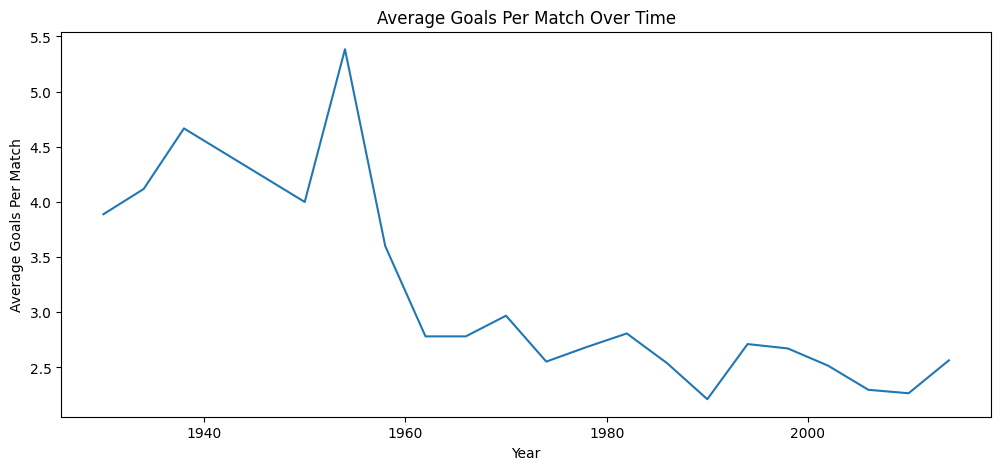

In [13]:
fig, ax = plt.subplots(figsize= (12, 5))
sns.lineplot(x=avg_goals.index, y=avg_goals.values, markers='o')
ax.set_title('Average Goals Per Match Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Average Goals Per Match')
plt.savefig('../visualizations/avg_goals_over_time.png')
plt.show()

In [14]:
# who won also show
df_matches['result'] = np.where(
    df_matches['home_team_goals'] > df_matches['away_team_goals'], 'Home Win',
    np.where(
        df_matches['home_team_goals'] < df_matches['away_team_goals'], 'Away Win',
        'Draw'
    )
)
df_matches['result'].value_counts()

result
Home Win    486
Draw        190
Away Win    174
Name: count, dtype: int64